# 05 — MAPPO Training Loop

This notebook demonstrates the `crowdrl-train` package: the full MAPPO (Multi-Agent PPO)
training pipeline for learning pedestrian navigation policies.

We cover:
1. **Architecture**: Actor-Critic networks with literature-grounded defaults
2. **Rollout collection**: Gathering experience from CrowdEnv
3. **GAE computation**: Per-agent advantage estimation with mid-episode termination
4. **PPO update**: Clipped surrogate loss, separate actor/critic optimizers
5. **Observation normalisation**: Welford's running statistics
6. **Curriculum**: Phase-based difficulty progression
7. **Mini training run**: End-to-end loop on a small environment

All design decisions are grounded in:
- Yu et al. (2022) "The Surprising Effectiveness of PPO in Cooperative MARL"
- Andrychowicz et al. (2021) "What Matters In On-Policy RL?"
- Huang et al. (2022) "The 37 Implementation Details of PPO"

See `plan/MAPPO_Literature_Review.md` for the full literature review.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from crowdrl_env import CrowdEnv, CrowdEnvConfig, GeometryConfig, GeometryTier, SpawnConfig
from crowdrl_env.solvability import SolvabilityMode

from crowdrl_train.config import NetworkConfig, PPOConfig, CurriculumConfig, TrainConfig
from crowdrl_train.networks import Actor, Critic, ActorCritic
from crowdrl_train.buffer import RolloutBuffer, FlatBatch
from crowdrl_train.normalizer import RunningNormalizer, RewardNormalizer
from crowdrl_train.mappo import MAPPOUpdater
from crowdrl_train.curriculum import CurriculumManager, EpisodeStats
from crowdrl_train.train import collect_episode

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cpu")
print(f"PyTorch {torch.__version__}, device: {device}")

PyTorch 2.6.0+cu126, device: cpu


## 1. Actor-Critic Architecture

The network architecture follows established best practices:

| Decision | Choice | Source |
|----------|--------|--------|
| Separate actor/critic | Yes | Andrychowicz et al. (2021): outperformed shared trunk on 4/5 envs |
| Activation | tanh | Andrychowicz et al. (2021): beat ReLU on 4/5 envs |
| Initialization | Orthogonal | Huang et al. (2022): sqrt(2) hidden, 0.01 actor out, 1.0 critic out |
| Policy std | State-independent log_std | Standard for continuous control (Huang et al. 2022, detail #24) |
| Initial std | 0.5 | Andrychowicz et al. (2021): optimal across most envs |

In [2]:
# Create networks with small hidden sizes for this demo
net_config = NetworkConfig(
    obs_dim=79, action_dim=4,
    actor_hidden_sizes=(64, 64),
    critic_hidden_sizes=(64, 64),
)
ac = ActorCritic(net_config)

# Count parameters
actor_params = sum(p.numel() for p in ac.actor.parameters())
critic_params = sum(p.numel() for p in ac.critic.parameters())
print(f"Actor:  {actor_params:,} parameters")
print(f"Critic: {critic_params:,} parameters")
print(f"Total:  {actor_params + critic_params:,} parameters")
print(f"\nInitial policy std: {ac.actor.log_std.exp().detach().numpy()}")
print(f"Actor and critic share NO parameters: {set(id(p) for p in ac.actor.parameters()).isdisjoint(set(id(p) for p in ac.critic.parameters()))}")

Actor:  9,544 parameters
Critic: 9,345 parameters
Total:  18,889 parameters

Initial policy std: [0.5 0.5 0.5 0.5]
Actor and critic share NO parameters: True


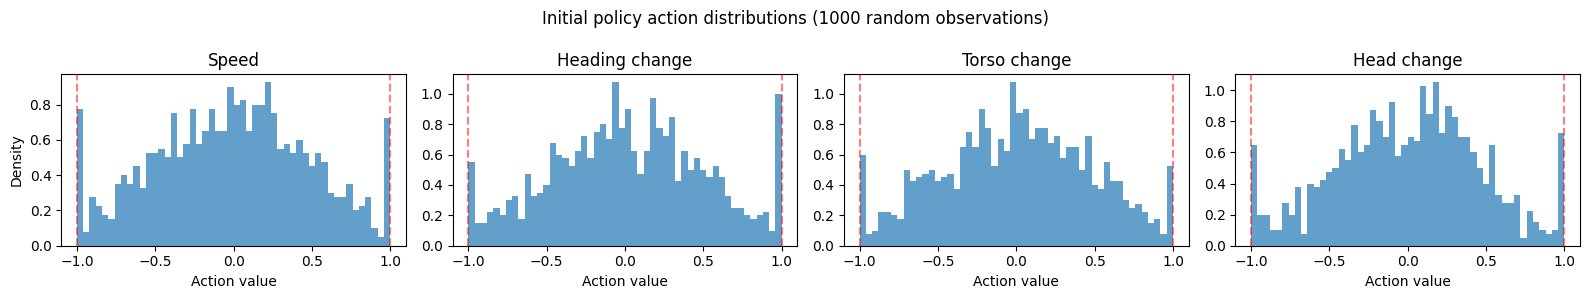

Value predictions: mean=0.0220, std=0.6424
Entropy: mean=2.9032 (higher = more exploration)


In [3]:
# Examine the action distribution
obs = torch.randn(1000, 79)
with torch.no_grad():
    actions, raw_actions, log_probs, entropy, values = ac.get_action_and_value(obs)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
action_names = ["Speed", "Heading change", "Torso change", "Head change"]
for i, (ax, name) in enumerate(zip(axes, action_names)):
    ax.hist(actions[:, i].numpy(), bins=50, density=True, alpha=0.7)
    ax.set_title(f"{name}")
    ax.set_xlabel("Action value")
    ax.axvline(-1, color="red", linestyle="--", alpha=0.5, label="clip bounds")
    ax.axvline(1, color="red", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Density")
fig.suptitle("Initial policy action distributions (1000 random observations)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Value predictions: mean={values.mean():.4f}, std={values.std():.4f}")
print(f"Entropy: mean={entropy.mean():.4f} (higher = more exploration)")

## 2. Rollout Collection

The `collect_episode` function runs one full episode in CrowdEnv, collecting:
- Observations (normalised via running statistics)
- Raw (unclipped) actions + log-probabilities (for PPO importance sampling)
- Rewards, value estimates, done flags, and active masks

Key design: variable agent counts are handled natively — no padding needed.

In [4]:
# Create a small environment
env_config = CrowdEnvConfig(
    geometry=GeometryConfig(tier=GeometryTier.TIER_0, min_side=10.0, max_side=12.0),
    spawn=SpawnConfig(n_agents_range=(5, 8)),
    max_steps=50,
)
env = CrowdEnv(config=env_config, seed=42)

# Create buffer and normalizer
buffer = RolloutBuffer(obs_dim=79, action_dim=4, device=device)
obs_normalizer = RunningNormalizer(shape=(79,))

# Collect one episode
ep_stats = collect_episode(env, ac, buffer, obs_normalizer, None, device)

print("Episode statistics:")
for k, v in ep_stats.items():
    print(f"  {k}: {v}")
print(f"\nBuffer: {buffer.total_steps} timesteps, {buffer.total_active_agent_steps} active agent-steps")

Episode statistics:
  n_agents: 6
  episode_length: 50
  goal_rate: 0.0
  n_reached_goal: 0
  mean_reward: -13.316463783070825
  total_reward: -79.89878269842495
  n_collisions: 0
  geometry_tier: TIER_0

Buffer: 50 timesteps, 300 active agent-steps


## 3. GAE Computation

Generalized Advantage Estimation (Schulman et al. 2016) computes advantages:

$$\hat{A}_t = \sum_{l=0}^{T-t} (\gamma \lambda)^l \delta_{t+l}$$
$$\delta_t = r_t + \gamma V(s_{t+1})(1 - d_t) - V(s_t)$$

Our implementation handles:
- **Per-agent termination**: when `done[agent]=True`, that agent's advantage chain resets
- **Inactive agents**: excluded from the batch entirely (get zero advantage)
- **Episode boundaries**: multiple episodes can be stored, each processed independently

In [5]:
# Compute GAE (episode ended naturally, so bootstrap values = 0)
n_agents = ep_stats["n_agents"]
last_values = np.zeros(n_agents)
last_dones = np.ones(n_agents, dtype=np.bool_)  # episode ended

buffer.compute_gae(last_values, last_dones, gamma=0.99, gae_lambda=0.95)

# Flatten into a training batch
batch = buffer.flatten()
print(f"Flat batch size: {batch.batch_size} active agent-steps")
print(f"Obs shape: {batch.obs.shape}")
print(f"Actions shape: {batch.actions_raw.shape}")
print(f"Advantages: mean={batch.advantages.mean():.4f}, std={batch.advantages.std():.4f}")
print(f"Returns: mean={batch.returns.mean():.4f}, std={batch.returns.std():.4f}")

Flat batch size: 300 active agent-steps
Obs shape: torch.Size([300, 79])
Actions shape: torch.Size([300, 4])
Advantages: mean=-3.9602, std=3.5943
Returns: mean=-3.8376, std=3.4507


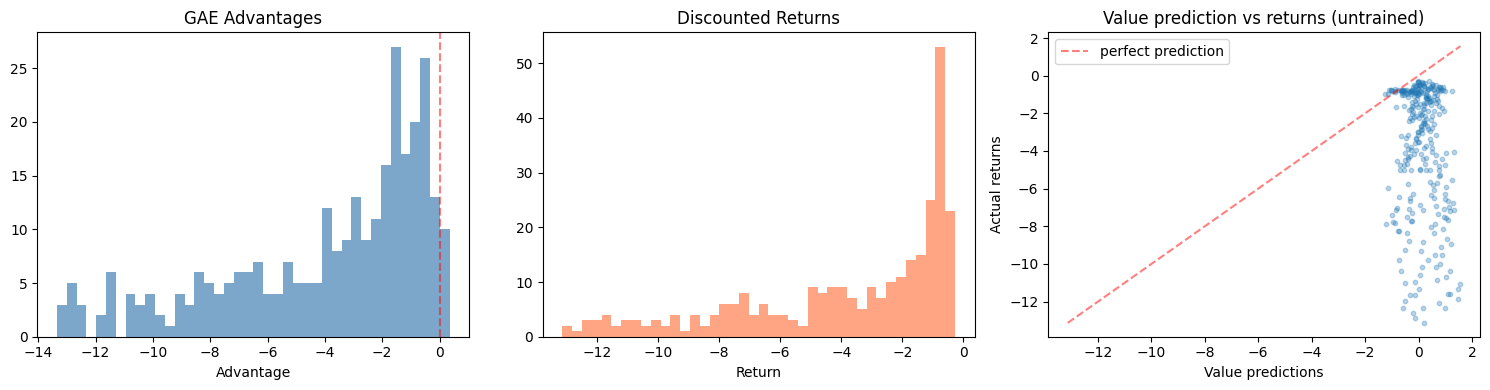

In [6]:
# Visualise advantages and returns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(batch.advantages.numpy(), bins=40, alpha=0.7, color="steelblue")
axes[0].set_title("GAE Advantages")
axes[0].set_xlabel("Advantage")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

axes[1].hist(batch.returns.numpy(), bins=40, alpha=0.7, color="coral")
axes[1].set_title("Discounted Returns")
axes[1].set_xlabel("Return")

axes[2].scatter(batch.values.numpy(), batch.returns.numpy(), alpha=0.3, s=10)
lims = [min(batch.values.min(), batch.returns.min()).item(),
        max(batch.values.max(), batch.returns.max()).item()]
axes[2].plot(lims, lims, "r--", alpha=0.5, label="perfect prediction")
axes[2].set_xlabel("Value predictions")
axes[2].set_ylabel("Actual returns")
axes[2].set_title("Value prediction vs returns (untrained)")
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. PPO Update

The MAPPO update applies standard PPO with these literature-informed choices:

| Setting | Value | Rationale |
|---------|-------|-----------|
| Full-batch | n_minibatches=1 | Yu et al. (2022): "Avoid splitting data into mini-batches" for MARL |
| Value loss | MSE (no clipping) | Andrychowicz et al. (2021): clipping "hurts regardless of threshold" |
| Gradient clip | max_norm=10.0 | Yu et al. (2022): more permissive than standard 0.5 |
| KL early stopping | target_kl=0.02 | Prevents destructive large updates |
| LR schedule | Linear decay to 0 | Standard for on-policy methods |

In [7]:
# Create the PPO updater
ppo_config = PPOConfig(
    lr_actor=5e-4, lr_critic=5e-4,
    n_epochs=5,   # fewer epochs for this demo
    n_minibatches=1,
    target_kl=0.02,
)
updater = MAPPOUpdater(ac, ppo_config, device)

# Run a single PPO update on the collected batch
metrics = updater.update(batch)

print("PPO Update metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.6f}")

PPO Update metrics:
  policy_loss: -0.015273
  value_loss: 13.855040
  entropy: 2.905162
  approx_kl: 0.001566
  clip_fraction: 0.014000
  explained_variance: -0.084944
  n_epochs_actual: 5.000000


## 5. Observation Normalisation

Running normalisation using Welford's online algorithm (Andrychowicz et al. 2021:
"Always use observation normalisation"). Observations are shifted to zero mean,
unit variance, and clipped to [-10, 10] to prevent outliers from destabilising training.

Normalizer has seen 300 observation vectors
Running mean (first 10 dims): [ 0.8092  0.3296  0.7072 -0.0292  0.7219  0.     -0.0879 -0.0174  0.0433
 -0.2477]
Running std  (first 10 dims): [2.478e-01 4.185e-01 3.135e-01 1.450e-01 3.150e-01 6.000e-04 9.341e-01
 4.158e-01 3.607e-01 4.819e-01]


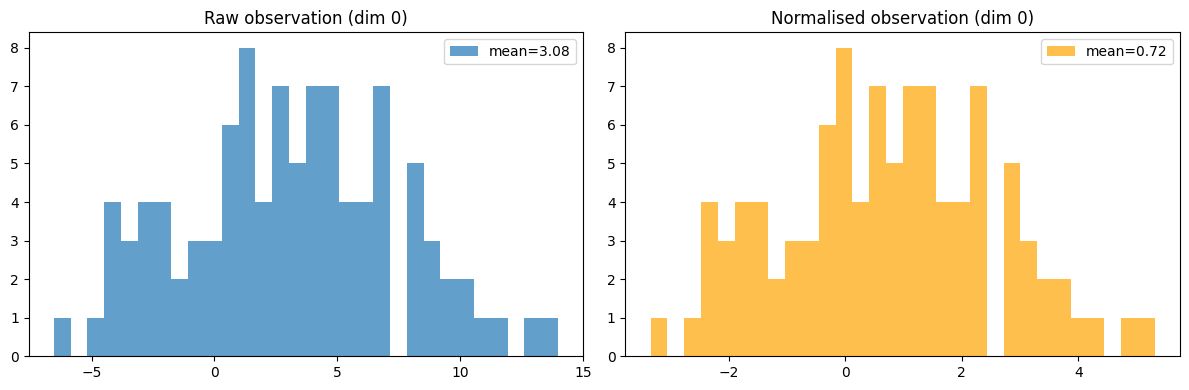

In [8]:
# Show normalizer state after collecting one episode
print(f"Normalizer has seen {obs_normalizer.count:.0f} observation vectors")
print(f"Running mean (first 10 dims): {obs_normalizer.mean[:10].round(4)}")
print(f"Running std  (first 10 dims): {np.sqrt(obs_normalizer.var[:10]).round(4)}")

# Demonstrate normalization effect
raw_obs = np.random.randn(100, 79) * 5 + 3  # Off-centre, high variance
obs_normalizer.update(raw_obs)
normed = obs_normalizer.normalize(raw_obs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw_obs[:, 0], bins=30, alpha=0.7, label=f"mean={raw_obs[:, 0].mean():.2f}")
axes[0].set_title("Raw observation (dim 0)")
axes[0].legend()
axes[1].hist(normed[:, 0], bins=30, alpha=0.7, color="orange",
             label=f"mean={normed[:, 0].mean():.2f}")
axes[1].set_title("Normalised observation (dim 0)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Curriculum Learning

The curriculum manager tracks a rolling goal rate and advances through difficulty
phases when the agent consistently reaches goals. This follows the Zone of Proximal
Development principle (Narvekar et al. 2020).

Default phases:
1. **Easy**: Tier 0 only, 5–15 agents, advance at 70% goal rate
2. **Medium**: Tier 0–1, 10–30 agents, advance at 60% goal rate
3. **Hard**: Tier 1–2, 20–50 agents, advance at 50% goal rate
4. **Full**: All tiers, 20–100 agents (terminal phase)

In [9]:
curriculum = CurriculumManager(CurriculumConfig())

print(f"Starting phase: {curriculum.current_phase.name}")
print(f"Phases:")
for i, phase in enumerate(curriculum.config.phases):
    tiers = [t.name for t in phase.geometry_tiers]
    marker = " <-- current" if i == curriculum.current_phase_idx else ""
    print(f"  {i}. {phase.name}: tiers={tiers}, agents={phase.n_agents_range}, "
          f"threshold={phase.goal_rate_threshold}{marker}")

# Simulate phase advancement
print(f"\nSimulating episodes with improving goal rate...")
for ep in range(300):
    # Simulate gradually improving performance
    goal_rate = min(0.9, 0.3 + ep * 0.003)
    stats = EpisodeStats(goal_rate=goal_rate, n_agents=10, episode_length=50, mean_reward=-5.0)
    advanced = curriculum.report_episode(stats)
    if advanced:
        print(f"  Episode {ep}: Advanced to phase '{curriculum.current_phase.name}' "
              f"(rolling goal rate: {curriculum.rolling_goal_rate:.2f})")

Starting phase: easy
Phases:
  0. easy: tiers=['TIER_0'], agents=(5, 15), threshold=0.7 <-- current
  1. medium: tiers=['TIER_0', 'TIER_1'], agents=(10, 30), threshold=0.6
  2. hard: tiers=['TIER_1', 'TIER_2'], agents=(20, 50), threshold=0.5
  3. rooms: tiers=['TIER_2', 'TIER_3A'], agents=(15, 40), threshold=0.5
  4. complex: tiers=['TIER_3A', 'TIER_3B'], agents=(20, 60), threshold=0.4
  5. full: tiers=['TIER_0', 'TIER_1', 'TIER_2', 'TIER_3A', 'TIER_3B'], agents=(20, 100), threshold=0.0

Simulating episodes with improving goal rate...
  Episode 199: Advanced to phase 'medium' (rolling goal rate: 0.00)


## 7. Training Run on GPU

Now let's run a proper training loop on CUDA. With 200 episodes, larger environments,
and the full 50-step horizon, we should see the policy start learning goal-directed
behaviour.

In [10]:
# Fresh networks + environment for the training run
torch.manual_seed(0)
np.random.seed(0)

train_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {train_device}", end="")
if train_device.type == "cuda":
    print(f" ({torch.cuda.get_device_name(0)})")
else:
    print()

net_cfg = NetworkConfig(
    obs_dim=79, action_dim=4,
    actor_hidden_sizes=(128, 128),
    critic_hidden_sizes=(128, 128),
)
ac = ActorCritic(net_cfg).to(train_device)
ac = torch.compile(ac)  # fuse forward passes

actor_params = sum(p.numel() for p in ac.actor.parameters())
critic_params = sum(p.numel() for p in ac.critic.parameters())
print(f"Network: {actor_params + critic_params:,} parameters (actor: {actor_params:,}, critic: {critic_params:,})")

ppo_cfg = PPOConfig(lr_actor=3e-4, lr_critic=3e-4, n_epochs=10, n_minibatches=4)
updater = MAPPOUpdater(ac, ppo_cfg, train_device)

env_cfg = CrowdEnvConfig(
    geometry=GeometryConfig(tier=GeometryTier.TIER_0, min_side=8.0, max_side=15.0),
    spawn=SpawnConfig(n_agents_range=(5, 12)),
    max_steps=2000,
)
env = CrowdEnv(config=env_cfg, seed=0)

buffer = RolloutBuffer(79, 4, train_device)
obs_norm = RunningNormalizer(shape=(79,))

N_EPISODES = 200
history = {"episode": [], "goal_rate": [], "mean_reward": [], "n_agents": [],
           "policy_loss": [], "value_loss": [], "entropy": [], "approx_kl": [],
           "explained_variance": []}

import time
t0 = time.time()
total_agent_steps = 0

print(f"\nTraining for {N_EPISODES} episodes...\n")
for ep in range(N_EPISODES):
    # Collect
    stats = collect_episode(env, ac, buffer, obs_norm, None, train_device)
    
    # GAE
    n = stats["n_agents"]
    buffer.compute_gae(np.zeros(n), np.ones(n, dtype=np.bool_), gamma=0.99, gae_lambda=0.95)
    
    # PPO Update
    batch = buffer.flatten()
    if batch.batch_size > 0:
        metrics = updater.update(batch)
        total_agent_steps += batch.batch_size
    else:
        metrics = {"policy_loss": 0, "value_loss": 0, "entropy": 0, "approx_kl": 0,
                   "explained_variance": 0}
    buffer.clear()
    
    # Record
    history["episode"].append(ep)
    history["goal_rate"].append(stats["goal_rate"])
    history["mean_reward"].append(stats["mean_reward"])
    history["n_agents"].append(stats["n_agents"])
    history["policy_loss"].append(metrics["policy_loss"])
    history["value_loss"].append(metrics["value_loss"])
    history["entropy"].append(metrics["entropy"])
    history["approx_kl"].append(metrics["approx_kl"])
    history["explained_variance"].append(metrics.get("explained_variance", 0))
    
    if (ep + 1) % 10 == 0:
        elapsed = time.time() - t0
        recent_goal = np.mean(history["goal_rate"][-50:])
        recent_reward = np.mean(history["mean_reward"][-50:])
        print(f"  Episode {ep+1:>4}: goal_rate(50)={recent_goal:.2f}, "
              f"reward(50)={recent_reward:.1f}, "
              f"entropy={metrics['entropy']:.3f}, ev={metrics.get('explained_variance', 0):.3f}, "
              f"steps={total_agent_steps:,}, "
              f"sps={total_agent_steps/elapsed:.0f}")

elapsed = time.time() - t0
print(f"\nTraining complete: {total_agent_steps:,} agent-steps in {elapsed:.1f}s "
      f"({total_agent_steps/elapsed:.0f} steps/s)")

Training on: cuda (NVIDIA GeForce RTX 4090)
Network: 54,153 parameters (actor: 27,272, critic: 26,881)

Training for 200 episodes...

  Episode   10: goal_rate(50)=0.32, reward(50)=-99.4, entropy=3.002, ev=0.381, steps=129,078, sps=6386
  Episode   20: goal_rate(50)=0.62, reward(50)=-72.7, entropy=3.018, ev=0.348, steps=219,618, sps=6189
  Episode   30: goal_rate(50)=0.74, reward(50)=-60.0, entropy=3.083, ev=0.458, steps=328,907, sps=6305
  Episode   40: goal_rate(50)=0.78, reward(50)=-52.6, entropy=3.111, ev=0.449, steps=421,594, sps=6049
  Episode   50: goal_rate(50)=0.82, reward(50)=-44.7, entropy=3.152, ev=0.482, steps=496,065, sps=5976
  Episode   60: goal_rate(50)=0.94, reward(50)=-32.0, entropy=3.189, ev=0.388, steps=588,069, sps=5943
  Episode   70: goal_rate(50)=0.96, reward(50)=-27.7, entropy=3.237, ev=0.242, steps=666,577, sps=5954
  Episode   80: goal_rate(50)=0.92, reward(50)=-28.4, entropy=3.243, ev=0.477, steps=750,904, sps=5827
  Episode   90: goal_rate(50)=0.91, reward

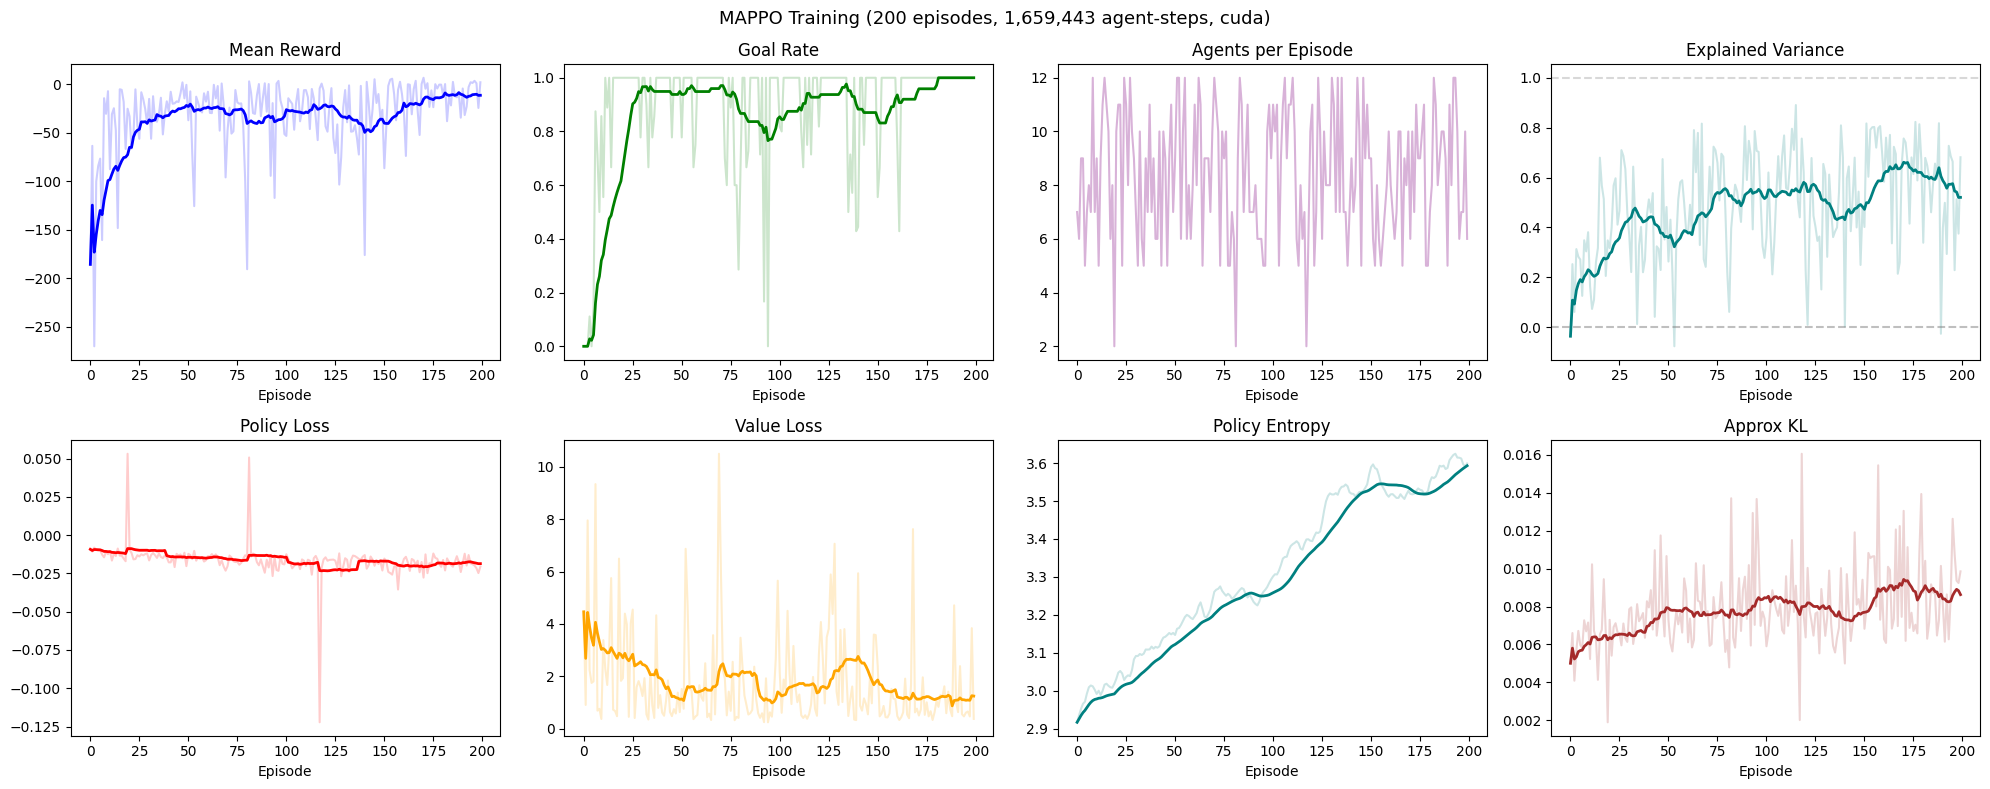

In [11]:
# Plot training curves with rolling averages
def rolling_mean(data, window=20):
    """Simple rolling mean for smoothing."""
    arr = np.array(data, dtype=np.float64)
    out = np.full_like(arr, np.nan)
    for i in range(len(arr)):
        start = max(0, i - window + 1)
        out[i] = arr[start:i+1].mean()
    return out

eps = np.array(history["episode"])
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Row 1: Episode metrics
axes[0, 0].plot(eps, history["mean_reward"], alpha=0.2, color="blue")
axes[0, 0].plot(eps, rolling_mean(history["mean_reward"]), "b-", linewidth=2)
axes[0, 0].set_title("Mean Reward")
axes[0, 0].set_xlabel("Episode")

axes[0, 1].plot(eps, history["goal_rate"], alpha=0.2, color="green")
axes[0, 1].plot(eps, rolling_mean(history["goal_rate"]), "g-", linewidth=2)
axes[0, 1].set_title("Goal Rate")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylim(-0.05, 1.05)

axes[0, 2].plot(eps, history["n_agents"], alpha=0.3, color="purple")
axes[0, 2].set_title("Agents per Episode")
axes[0, 2].set_xlabel("Episode")

axes[0, 3].plot(eps, history["explained_variance"], alpha=0.2, color="teal")
axes[0, 3].plot(eps, rolling_mean(history["explained_variance"]), color="teal", linewidth=2)
axes[0, 3].set_title("Explained Variance")
axes[0, 3].set_xlabel("Episode")
axes[0, 3].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0, 3].axhline(1, color="gray", linestyle="--", alpha=0.3)

# Row 2: PPO metrics
axes[1, 0].plot(eps, history["policy_loss"], alpha=0.2, color="red")
axes[1, 0].plot(eps, rolling_mean(history["policy_loss"]), "r-", linewidth=2)
axes[1, 0].set_title("Policy Loss")
axes[1, 0].set_xlabel("Episode")

axes[1, 1].plot(eps, history["value_loss"], alpha=0.2, color="orange")
axes[1, 1].plot(eps, rolling_mean(history["value_loss"]), color="orange", linewidth=2)
axes[1, 1].set_title("Value Loss")
axes[1, 1].set_xlabel("Episode")

axes[1, 2].plot(eps, history["entropy"], alpha=0.2, color="teal")
axes[1, 2].plot(eps, rolling_mean(history["entropy"]), color="teal", linewidth=2)
axes[1, 2].set_title("Policy Entropy")
axes[1, 2].set_xlabel("Episode")

axes[1, 3].plot(eps, history["approx_kl"], alpha=0.2, color="brown")
axes[1, 3].plot(eps, rolling_mean(history["approx_kl"]), color="brown", linewidth=2)
axes[1, 3].set_title("Approx KL")
axes[1, 3].set_xlabel("Episode")

fig.suptitle(f"MAPPO Training ({N_EPISODES} episodes, {total_agent_steps:,} agent-steps, {train_device})",
             fontsize=13)
plt.tight_layout()
plt.show()

## 8. Comparing Trained vs Untrained Policy

After 200 episodes of training, we compare the trained policy against a fresh
untrained network with the same architecture.

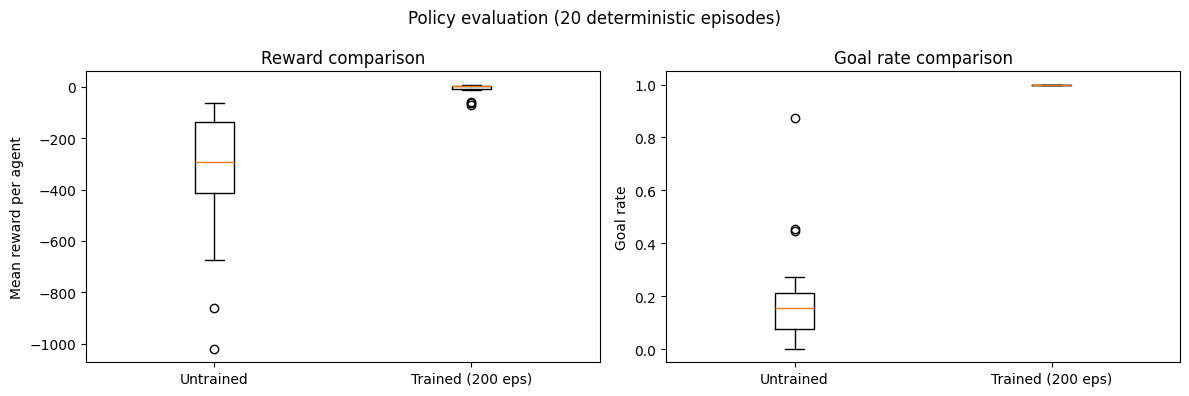

Untrained: reward=-360.49 +/- 257.61, goal_rate=0.19
Trained:   reward=-8.09 +/- 24.14, goal_rate=1.00


In [12]:
def evaluate_policy(env, actor_critic, obs_normalizer, n_episodes=10, device=train_device):
    """Evaluate a policy over multiple episodes (deterministic)."""
    results = []
    for seed in range(n_episodes):
        obs, info = env.reset(seed=seed + 1000)
        n = info["n_agents"]
        total_r = np.zeros(n)
        cum_done = np.zeros(n, dtype=np.bool_)
        
        for _ in range(env.config.max_steps):
            obs_n = obs_normalizer.normalize(obs) if obs_normalizer else obs
            with torch.no_grad():
                obs_t = torch.as_tensor(obs_n, dtype=torch.float32, device=device)
                actions, _, _, _, _ = actor_critic.get_action_and_value(obs_t, deterministic=True)
            obs, rewards, terminated, truncated, step_info = env.step(actions.cpu().numpy())
            total_r += rewards
            cum_done |= terminated
            if step_info["episode_over"]:
                break
        
        results.append({"goal_rate": cum_done.mean(), "mean_reward": total_r.mean(), "n_agents": n})
    return results


# Evaluate trained policy (20 episodes for more stable stats)
trained_results = evaluate_policy(env, ac, obs_norm, n_episodes=20)

# Create a fresh untrained policy for comparison
torch.manual_seed(99)
untrained_ac = ActorCritic(net_cfg).to(train_device)
untrained_norm = RunningNormalizer(shape=(79,))
untrained_norm.load_state_dict(obs_norm.state_dict())
untrained_results = evaluate_policy(env, untrained_ac, untrained_norm, n_episodes=20)

trained_rewards = [r["mean_reward"] for r in trained_results]
untrained_rewards = [r["mean_reward"] for r in untrained_results]
trained_goals = [r["goal_rate"] for r in trained_results]
untrained_goals = [r["goal_rate"] for r in untrained_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot([untrained_rewards, trained_rewards],
                tick_labels=["Untrained", f"Trained ({N_EPISODES} eps)"])
axes[0].set_ylabel("Mean reward per agent")
axes[0].set_title("Reward comparison")

axes[1].boxplot([untrained_goals, trained_goals],
                tick_labels=["Untrained", f"Trained ({N_EPISODES} eps)"])
axes[1].set_ylabel("Goal rate")
axes[1].set_title("Goal rate comparison")
axes[1].set_ylim(-0.05, 1.05)

plt.suptitle("Policy evaluation (20 deterministic episodes)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Untrained: reward={np.mean(untrained_rewards):.2f} +/- {np.std(untrained_rewards):.2f}, "
      f"goal_rate={np.mean(untrained_goals):.2f}")
print(f"Trained:   reward={np.mean(trained_rewards):.2f} +/- {np.std(trained_rewards):.2f}, "
      f"goal_rate={np.mean(trained_goals):.2f}")

## 9. Trained Policy Trajectories

Visualise the actual paths agents take under the trained policy across 4 different
randomly generated Tier 0 geometries. Each agent's trajectory is drawn from spawn
(circle) to final position (triangle), with goal positions shown as stars.

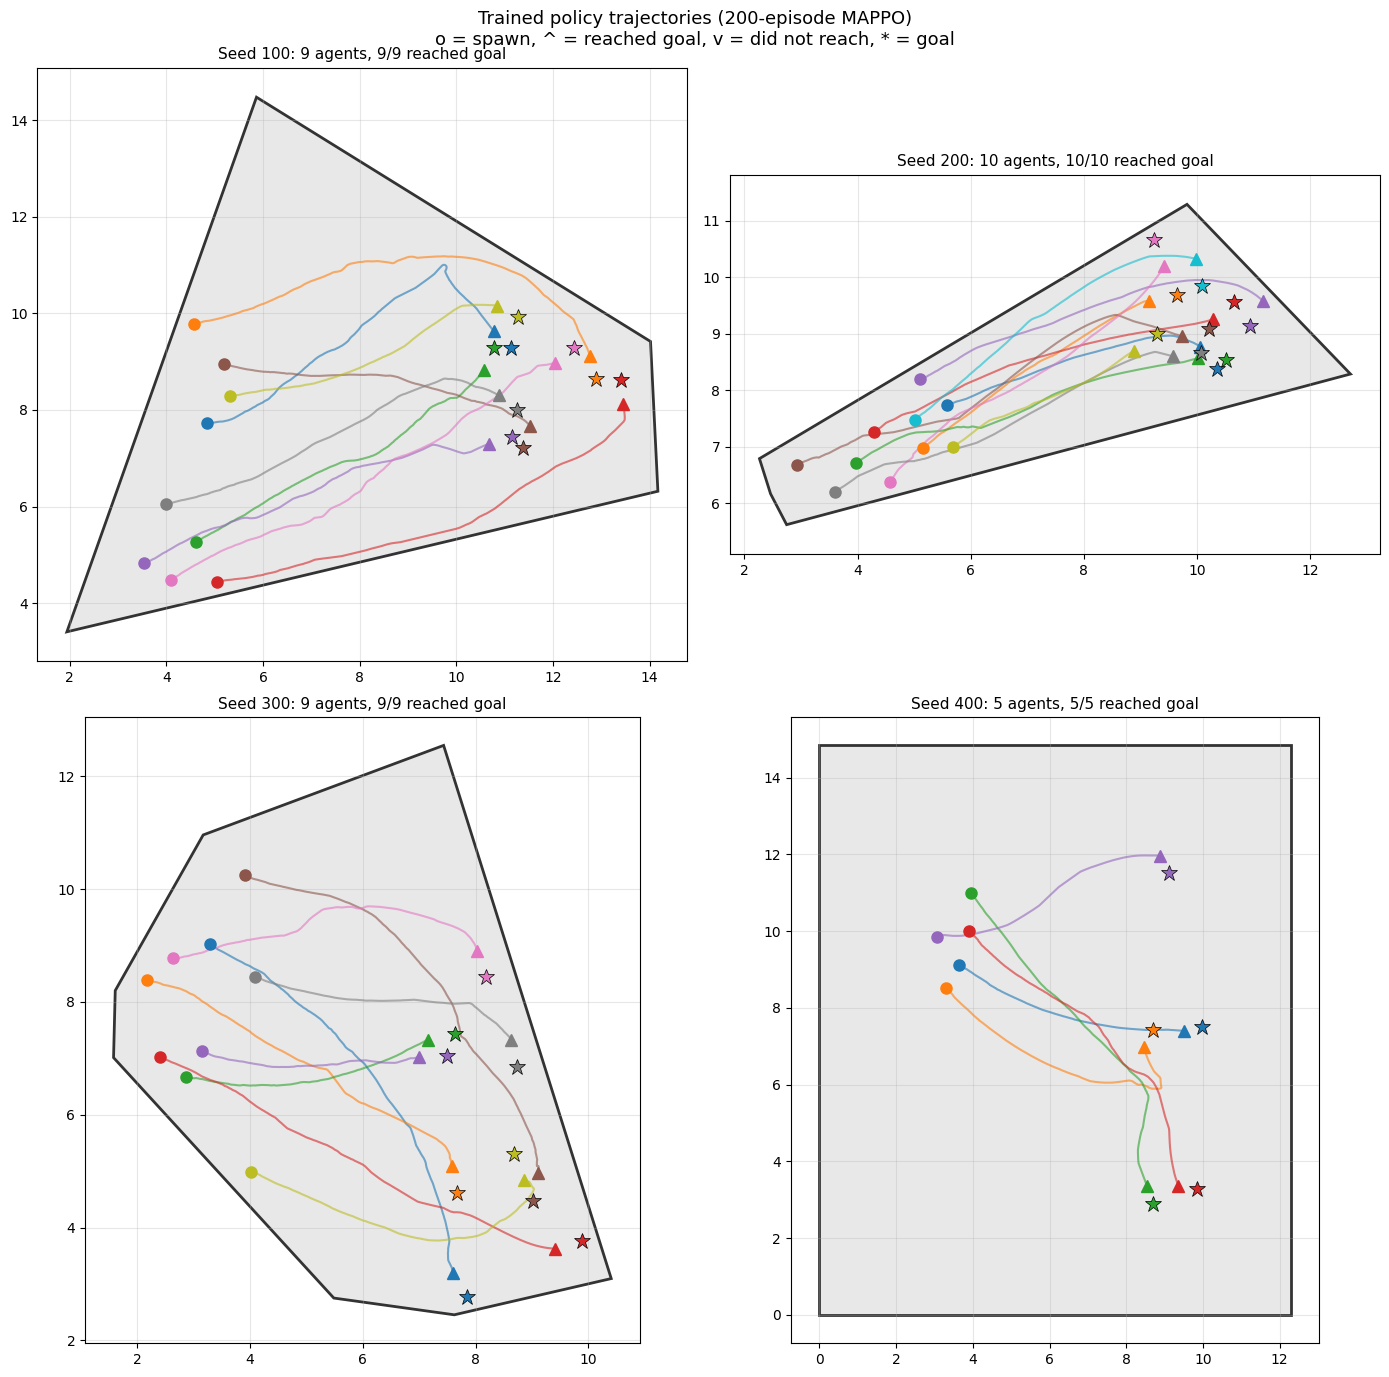

In [13]:
from crowdrl_env.visualiser import plot_geometry
import copy

def run_episode_with_trajectories(env, actor_critic, obs_normalizer, device, seed=0):
    """Run one episode and record per-agent position trajectories."""
    obs, info = env.reset(seed=seed)
    n = info["n_agents"]

    # Record initial state
    trajectories = [[] for _ in range(n)]
    for i in range(n):
        trajectories[i].append(env._world.positions[i].copy())

    goal_positions = env._world.goal_positions.copy()
    walkable_polygon = copy.deepcopy(env._world.walkable_polygon)
    cum_done = np.zeros(n, dtype=np.bool_)

    for _ in range(env.config.max_steps):
        obs_n = obs_normalizer.normalize(obs)
        with torch.no_grad():
            obs_t = torch.as_tensor(obs_n, dtype=torch.float32, device=device)
            actions, _, _, _, _ = actor_critic.get_action_and_value(obs_t, deterministic=True)
        obs, rewards, terminated, truncated, step_info = env.step(actions.cpu().numpy())

        for i in range(n):
            trajectories[i].append(env._world.positions[i].copy())
        cum_done |= terminated

        if step_info["episode_over"]:
            break

    return {
        "trajectories": [np.array(t) for t in trajectories],
        "goal_positions": goal_positions,
        "walkable_polygon": walkable_polygon,
        "reached_goal": cum_done,
        "n_agents": n,
    }


# Run 4 episodes with different seeds for diverse geometries
vis_env = CrowdEnv(config=env_cfg, seed=0)
cmap = plt.cm.tab10

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, (ax, seed) in enumerate(zip(axes, [100, 200, 300, 400])):
    result = run_episode_with_trajectories(vis_env, ac, obs_norm, train_device, seed=seed)
    n = result["n_agents"]

    # Draw geometry
    plot_geometry(result["walkable_polygon"], ax=ax)

    # Draw each agent's trajectory
    for i in range(n):
        traj = result["trajectories"][i]
        color = cmap(i % 10)
        reached = result["reached_goal"][i]

        # Path line
        ax.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.6, linewidth=1.5, zorder=5)
        # Start position (circle)
        ax.plot(traj[0, 0], traj[0, 1], "o", color=color, markersize=8, zorder=6)
        # End position (triangle)
        ax.plot(traj[-1, 0], traj[-1, 1], "^" if reached else "v", color=color,
                markersize=8, zorder=6)
        # Goal (star)
        ax.plot(result["goal_positions"][i, 0], result["goal_positions"][i, 1],
                "*", color=color, markersize=12, markeredgecolor="black",
                markeredgewidth=0.5, zorder=7)

    n_reached = int(result["reached_goal"].sum())
    ax.set_title(f"Seed {seed}: {n} agents, {n_reached}/{n} reached goal",
                 fontsize=11)

fig.suptitle(f"Trained policy trajectories ({N_EPISODES}-episode MAPPO)\n"
             "o = spawn, ^ = reached goal, v = did not reach, * = goal",
             fontsize=13)
plt.tight_layout()
plt.show()

## 10. Configuration & CLI

The full training loop is configured via `TrainConfig`, which composes all sub-configs
and supports JSON serialisation for reproducibility. It can be launched from the CLI:

```bash
# Default config
uv run crowdrl-train

# Custom config file
uv run crowdrl-train --config my_config.json

# Override specific settings
uv run crowdrl-train --seed 123 --total-timesteps 1000000 --device cuda

# Resume from checkpoint
uv run crowdrl-train --resume checkpoints/checkpoint_500.pt
```

In [14]:
# Show the configuration used for this training run
config = TrainConfig(
    network=net_cfg,
    ppo=ppo_cfg,
    total_timesteps=total_agent_steps,
    device=str(train_device),
)

import json
config_dict = config.to_dict()
# Pretty-print selected sections
print("=== Network Config ===")
print(json.dumps(config_dict["network"], indent=2))
print("\n=== PPO Config ===")
print(json.dumps(config_dict["ppo"], indent=2))
print("\n=== Curriculum Phases ===")
for p in config_dict["curriculum"]["phases"]:
    print(f"  {p['name']}: tiers={p['geometry_tiers']}, agents={p['n_agents_range']}, threshold={p['goal_rate_threshold']}")

=== Network Config ===
{
  "obs_dim": 79,
  "action_dim": 4,
  "actor_hidden_sizes": [
    128,
    128
  ],
  "critic_hidden_sizes": [
    128,
    128
  ],
  "activation": "tanh",
  "ortho_init": true,
  "log_std_init": -0.6931471805599453,
  "critic_obs_dim": null
}

=== PPO Config ===
{
  "lr_actor": 0.0003,
  "lr_critic": 0.0003,
  "adam_eps": 1e-05,
  "gamma": 0.99,
  "gae_lambda": 0.95,
  "clip_epsilon": 0.2,
  "entropy_coef": 0.01,
  "value_coef": 0.5,
  "max_grad_norm": 10.0,
  "n_epochs": 10,
  "n_minibatches": 4,
  "target_kl": 0.02,
  "lr_schedule": "cosine",
  "normalize_advantages": true,
  "use_value_clip": false,
  "use_huber_loss": false,
  "huber_delta": 10.0
}

=== Curriculum Phases ===
  easy: tiers=['TIER_0'], agents=[5, 15], threshold=0.7
  medium: tiers=['TIER_0', 'TIER_1'], agents=[10, 30], threshold=0.6
  hard: tiers=['TIER_1', 'TIER_2'], agents=[20, 50], threshold=0.5
  rooms: tiers=['TIER_2', 'TIER_3A'], agents=[15, 40], threshold=0.5
  complex: tiers=['TIER_

## Summary

The `crowdrl-train` package provides a complete MAPPO training pipeline:

| Component | Module | Key features |
|-----------|--------|-------------|
| Networks | `networks.py` | Separate actor/critic, ortho init, diagonal Gaussian |
| Buffer | `buffer.py` | Variable agent counts, per-agent GAE, no padding |
| PPO | `mappo.py` | Full-batch update, MSE value loss, KL early stopping |
| Normalisation | `normalizer.py` | Welford's running stats, reward std normalisation |
| Curriculum | `curriculum.py` | Success-rate-driven phase advancement |
| Training | `train.py` | Full loop + CLI + checkpointing + ONNX export |
| Vec Env | `vec_env.py` | Subprocess-parallel CrowdEnvs with central GPU inference |
| Collector | `rollout_collector.py` | Multi-env batched collection with per-episode GAE bootstrap |
| Config | `config.py` | Frozen dataclasses with JSON serialisation |
| Export | `export.py` | PyTorch -> ONNX with embedded normalisation |

**Scaling up**: For full training runs, use `SubprocVecEnv` to run N environments
in parallel — see `examples/06_full_training.ipynb` for a vectorized run with
32 workers, 5000 collect-update rollouts, and curriculum progression through geometry tiers.

All hyperparameter defaults are grounded in peer-reviewed literature.
See `plan/MAPPO_Literature_Review.md` for the complete rationale.